In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
df = pd.read_csv("C:/Users/kevinjfei/python_decal_fa25/course_assignments/homework9/noisy_curvefit_data.csv")

In [5]:
df.head


<bound method NDFrame.head of            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0  -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1  -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2  -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3  -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4  -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
..       ...        ...        ...        ...        ...        ...
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

[100 rows x 6 columns]>

In [6]:
df.shape

(100, 6)

In [7]:
df.tail

<bound method NDFrame.tail of            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0  -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1  -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2  -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3  -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4  -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
..       ...        ...        ...        ...        ...        ...
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

[100 rows x 6 columns]>

In [8]:
df.info

<bound method DataFrame.info of            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0  -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1  -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2  -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3  -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4  -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
..       ...        ...        ...        ...        ...        ...
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

[100 rows x 6 columns]>

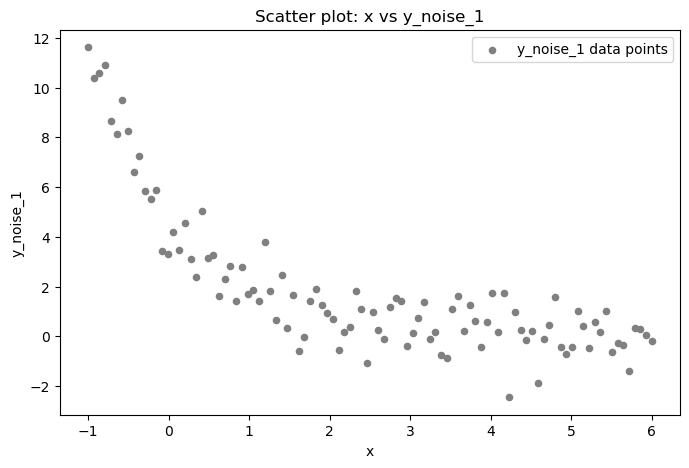

In [10]:
x = df["x"]
y1 = df["y_noise_1"]

plt.figure(figsize=(8,5))
plt.scatter(x, y1, s=20, label="y_noise_1 data points", color="gray")
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.title("Scatter plot: x vs y_noise_1")
plt.legend()
plt.show()

In [19]:
def model(x, A, k):
    return A * np.exp(-k * x)

popt, pcov = curve_fit(model, x, y1, p0 = [1, 1])
A_fit, k_fit = popt

print(f"Fit: y = {A_fit: .2f} * e^(-{k_fit:.2f} * x)")

residuals = y1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

Fit: y =  4.71 * e^(-0.92 * x)


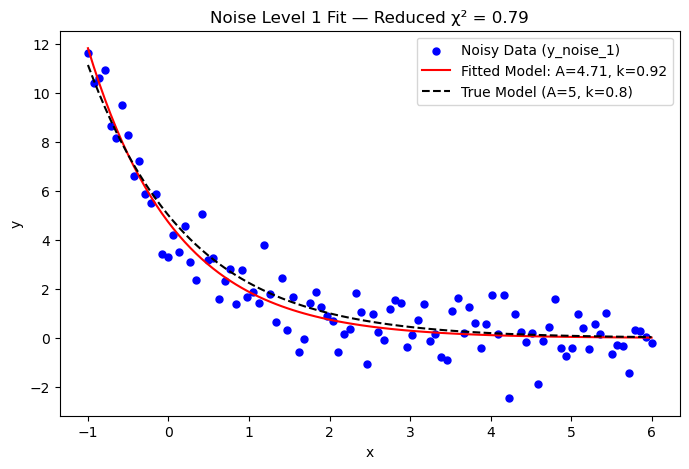

In [20]:
A_true = 5
k_true = 0.8
y_true = model(x, A_true, k_true)
y_fit = model(x, A_fit, k_fit)

plt.figure(figsize=(8,5))
plt.scatter(x, y1, label="Noisy Data (y_noise_1)", color="blue", s=25)
plt.plot(x, y_fit, label=f"Fitted Model: A={A_fit:.2f}, k={k_fit:.2f}", color="red")
plt.plot(x, y_true, label="True Model (A=5, k=0.8)", color="black", linestyle="--")
plt.title(f"Noise Level 1 Fit — Reduced χ² = {chi2_reduced:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

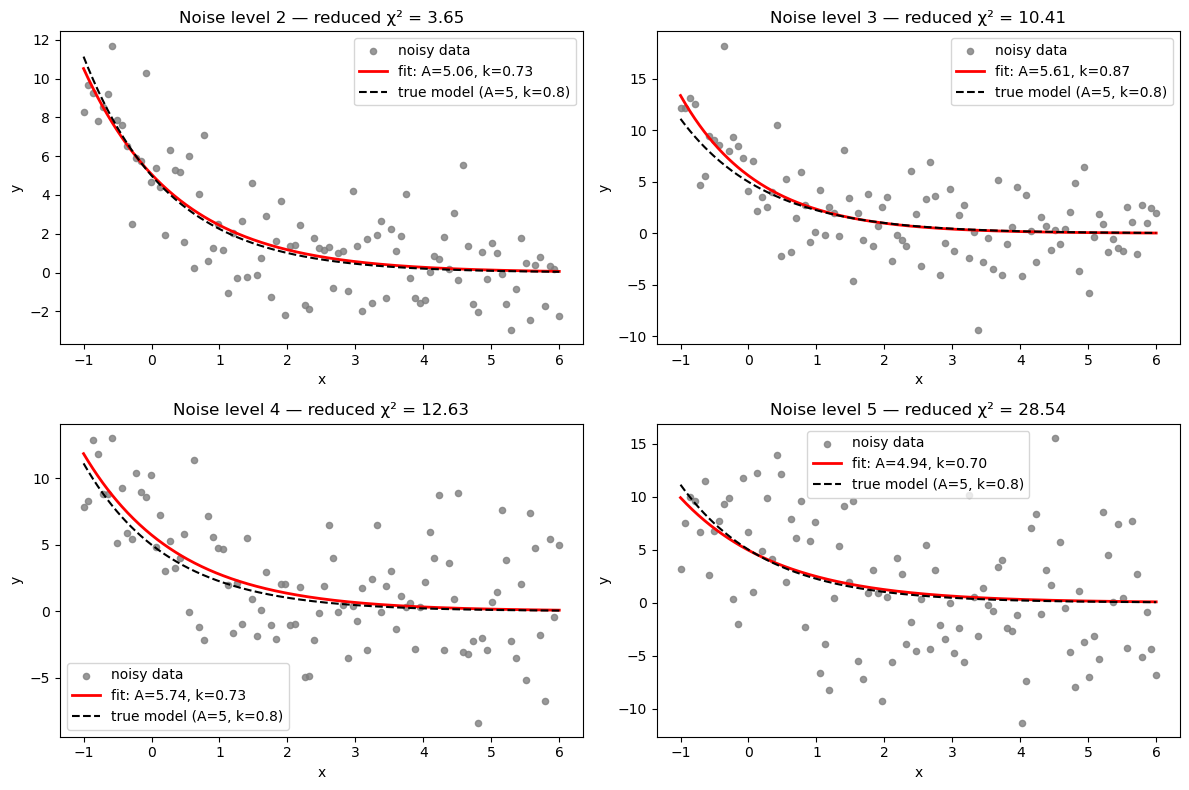

In [21]:
y2 = df["y_noise_2"]
y3 = df["y_noise_3"]
y4 = df["y_noise_4"]
y5 = df["y_noise_5"]

def fit_model(x, y,):
    popt, pcov = curve_fit(model, x, y)
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return {
        "A_fit": float(A_fit),
        "k_fit": float(k_fit),
        "chi2_reduced": float(chi2_reduced),
    }



noise_columns = [y2, y3, y4, y5]
noise_levels = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
x_fine = np.linspace(x.min(), x.max(), 400) 

for ax, y_noise, lvl in zip(axes, noise_columns, noise_levels):
    res = fit_model(x, y_noise)

    ax.scatter(x, y_noise, color="gray", s=20, label="noisy data", alpha=0.8)

    y_fit_line = model(x_fine, res["A_fit"], res["k_fit"])
    ax.plot(x_fine, y_fit_line, color="red", linewidth=2, label=f"fit: A={res['A_fit']:.2f}, k={res['k_fit']:.2f}")

    y_true_line = model(x_fine, 5, 0.8)
    ax.plot(x_fine, y_true_line, linestyle="--", color="black", linewidth=1.5, label="true model (A=5, k=0.8)")

    ax.set_title(f"Noise level {lvl} — reduced χ² = {res['chi2_reduced']:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()





In [ ]:
# chi squared increases because more noise = more variance
# black same, cuz it's constant. red stays somewhat similar too because
# even though more variance, it averages out to roughly the same line,
# since it is always based on the black line. 


In [22]:
all_results = []
all_ys = [y1, y2, y3, y4, y5]
for lvl, y in enumerate(all_ys, start=1):
    res = fit_model(x, y)
    all_results.append({
        "noise_level": lvl,
        "A_fit": res["A_fit"],
        "k_fit": res["k_fit"],
        "chi2_reduced": res["chi2_reduced"]
    })

results_df = pd.DataFrame(all_results)
print(results_df)

# Save to CSV
results_df.to_csv("noisy_parameters.csv", index=False)

   noise_level     A_fit     k_fit  chi2_reduced
0            1  4.714814  0.918308      0.790673
1            2  5.063889  0.730396      3.649382
2            3  5.609396  0.870372     10.410207
3            4  5.738727  0.725965     12.626832
4            5  4.943458  0.695012     28.538124
